# 🌷🛰️ Ejemplo resuelto · Proyecto **Centinela** — Fase 2: Sistema Multimodal del Tulipán
### Redes Neuronales — Deep Learning · Maestría en Ciencia de Datos · Universidad Santo Tomás

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JotaMao1985/Deep_Learning_Usta/blob/main/notebooks/06-ejemplo-centinela-fase2-tulipanes.ipynb)

Este cuaderno resuelve la Fase 2 del Proyecto Integrador *Centinela* de principio a fin, como **continuación directa** del [ejemplo de la Fase 1](05-ejemplo-centinela-fase1-tulipanes.ipynb). Es el gemelo resuelto del [andamiaje](04-scaffold-centinela-fase2.ipynb): donde allí hay `# TODO (estudiante)`, aquí hay las tres ramas entrenadas —visión, secuencia y fusión— sobre **datos reales**, con la razón de cada decisión.

**El paso de la Fase 1 a la Fase 2.** La Fase 1 aplanó el clima a una tabla y predijo la helada con un MLP (*recall* 0.683). La Fase 2 hace tres cosas: (1) reemplaza ese aplanamiento por una **red recurrente** que lee la secuencia de días; (2) incorpora por primera vez la **segunda modalidad** —imágenes de satélite **Sentinel-2** de las parcelas del polder— con una **CNN** y *transfer learning*; y (3) **fusiona** ambas ramas en una alerta por parcela.

> ⛔ **Este escenario sigue vetado como entrega.** El café es el único adoptable; el tulipán con datos KNMI/Sentinel-2 queda resuelto aquí a la vista de todos. De este cuaderno se reutiliza el listón de calidad, no el problema.

> 🔗 **Qué aporta cada modalidad (y por qué la fusión es honesta).** La imagen dice **qué parcelas son un cultivo sensible** (el tulipán) — una propiedad estable de la temporada. El clima dice **qué día amenaza una helada** — una señal que cambia día a día. La alerta de la Fase 2 cruza ambas: *este cultivo sensible* **y** *esta noche fría*. Ninguna modalidad sola basta, y eso es justo lo que la rúbrica premia en la fusión (30 %).

---
**Contenido**
0. Preparación del entorno
1. Los datos multimodales (Sentinel-2 + KNMI) y su clave de alineación
2. Rama A · Visión — CNN con *transfer learning* (clasificación de cultivo)
3. Rama B · Secuencia — RNN/LSTM/GRU (riesgo de helada), superando el MLP de la Fase 1
4. Rama C · Fusión multimodal y ablación *(sección siguiente)*
5. Cierre · Autoevaluación y anexos *(sección siguiente)*


## 0. Preparación del entorno

Se cargan las librerías del curso más **`torchvision`** (para los modelos preentrenados de la rama de imagen) y se fijan las semillas. El cuaderno corre en **CPU** por reproducibilidad; si hay GPU disponible, basta cambiar `DEVICE`. La paleta y el formato de miles siguen la convención del material.

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 1 · Preparación del entorno
# Qué hace · Importa librerías (incl. torchvision), fija semillas y estilo, elige CPU.
# Por qué  · Semillas + CPU dan resultados reproducibles para discutir números concretos.

# En Colab casi todo viene instalado. Si faltara algo, descomentar:
# !pip -q install torch torchvision scikit-learn pandas matplotlib

%matplotlib inline
import os, io, urllib.request
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import torchvision
from sklearn.metrics import classification_report, confusion_matrix

SEMILLA = 42
np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
DEVICE = "cpu"   # reproducible; para acelerar: "cuda" o "mps" si están disponibles

USTA_MORADO, USTA_ROSA, USTA_NAVY = "#3D008D", "#ED1E79", "#001A4D"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

def miles(n):
    """Formatea un entero con punto como separador de miles."""
    return f"{n:,}".replace(",", ".")

print("Entorno listo · torch", torch.__version__, "· torchvision", torchvision.__version__)


Entorno listo · torch 2.12.0 · torchvision 0.27.0


## 1. Los datos multimodales y su clave de alineación

**Resumen de la Propuesta de Datos de la Fase 2** (el documento completo va en el Anexo B):

| Elemento | Decisión |
|---|---|
| **Cliente** | Cooperativa de cultivadores de bulbos del Noordoostpolder (Flevoland, NL) — el mismo de la Fase 1. |
| **Rama de imagen** (nueva) | Parches **Sentinel-2** (10 m) de las parcelas del polder, etiquetados con el cultivo real del registro abierto neerlandés **BRP**. Tarea: clasificar el tipo de cultivo (tulipán y 5 más). |
| **Rama temporal** (de la Fase 1) | Serie diaria **KNMI 273 Marknesse**, ahora como **secuencia** de 14 días → riesgo de helada. |
| **Clave de alineación** | La imagen aporta una propiedad **por parcela** (¿es tulipán?); el clima aporta una señal **por día** (¿helada mañana?). La fusión (§4) cruza *parcela × día de campaña*. |

> ⚠️ **Honestidad sobre la alineación (se retoma con rigor en §4).** Las imágenes despejadas son de la temporada de crecimiento (abril–agosto), cuando **no hay heladas**; el clima puntual del KNMI es **el mismo para todas las parcelas** en un día dado. Por eso la fusión **no** empareja "fecha de imagen = fecha de helada" (sería un pareo artificial y una fuga de datos). El co-registro legítimo es *(parcela → cultivo)* × *(día → helada)*.

**Carga de datos.** Ambas modalidades vienen **cacheadas en el repositorio** (como el CSV del KNMI de la Fase 1): las imágenes ya recortadas en un `.npz` y la serie del KNMI en su CSV. Así el cuaderno corre en Colab sin geolibrerías ni credenciales. El `.npz` lo produjo el script `extraer_parches_fase2.py` (STAC de Sentinel-2 → parcelas BRP → recorte), incluido en el repo para transparencia.

In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 2 · Carga de las dos modalidades (cache local → espejo GitHub)
# Qué hace · Carga los parches Sentinel-2 (.npz) y la serie diaria del KNMI (.csv).
# Por qué  · Datos cacheados = el cuaderno corre igual en local y en Colab, offline.

DIR_DATOS = "data"
NPZ = "sentinel2_parches_polder.npz"
CSV_KNMI = "knmi_273_marknesse.csv"
RAW = "https://raw.githubusercontent.com/JotaMao1985/Deep_Learning_Usta/main/notebooks/data/"

def asegurar(nombre):
    ruta = os.path.join(DIR_DATOS, nombre)
    if os.path.exists(ruta):
        return ruta, "cache local"
    os.makedirs(DIR_DATOS, exist_ok=True)
    urllib.request.urlretrieve(RAW + nombre, ruta)
    return ruta, "espejo GitHub"

ruta_npz, f1 = asegurar(NPZ)
d = np.load(ruta_npz, allow_pickle=True)
X_img, y_img, parcela_id, fecha_img = d["X"], d["y"], d["parcela_id"], d["fecha"]
CLASES = [str(c) for c in d["clases"]]
print(f"Imágenes ({f1}): {X_img.shape}  ·  {len(CLASES)} clases: {CLASES}")
print(f"  parcelas únicas: {miles(len(np.unique(parcela_id)))}  ·  fechas: {sorted(set(fecha_img.tolist()))}")

ruta_csv, f2 = asegurar(CSV_KNMI)
knmi = pd.read_csv(ruta_csv, comment="#", header=None,
                   names=["STN","FECHA","TG","TN","TX","UG","RH","FG","Q"], skipinitialspace=True)
knmi["FECHA"] = pd.to_datetime(knmi["FECHA"], format="%Y%m%d")
knmi = knmi.sort_values("FECHA").reset_index(drop=True)
print(f"Clima KNMI ({f2}): {miles(len(knmi))} días  ({knmi.FECHA.min().date()} → {knmi.FECHA.max().date()})")


Imágenes (cache local): (840, 4, 32, 32)  ·  6 clases: ['cebolla', 'maiz', 'papa', 'remolacha', 'trigo', 'tulipan']
  parcelas únicas: 210  ·  fechas: ['2025-04-04', '2025-05-11', '2025-06-12', '2025-08-14']
Clima KNMI (cache local): 13.514 días  (1989-01-01 → 2025-12-31)


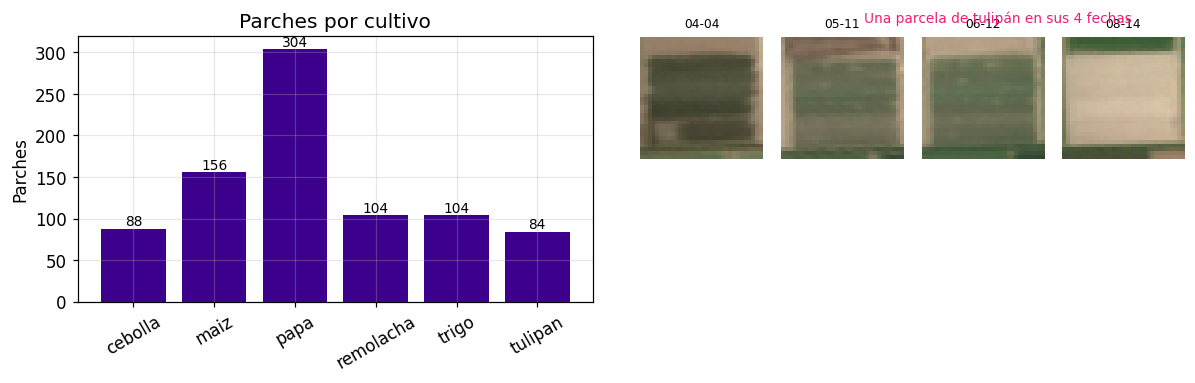

Balance por clase: {'cebolla': 88, 'maiz': 156, 'papa': 304, 'remolacha': 104, 'trigo': 104, 'tulipan': 84}
El tulipán es minoría — se tratará con pesos de clase y se leerá el recall por clase.


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 3 · EDA de la rama de imagen: balance de clases y fenología
# Qué hace · Grafica cuántos parches hay por cultivo y una parcela de tulipán en sus 4 fechas.
# Por qué  · El desbalance condiciona la lectura de métricas; la fenología muestra la señal visual.

def rgb(patch):
    """Parche (4,32,32) R,G,B,NIR → imagen true-color estirada para visualizar."""
    im = np.stack([patch[0], patch[1], patch[2]], -1).astype(float)
    return np.clip(im/3000, 0, 1) ** 0.7

fig = plt.figure(figsize=(11, 3.6))
ax1 = fig.add_subplot(1, 2, 1)
conteo = [int((y_img==i).sum()) for i in range(len(CLASES))]
ax1.bar(CLASES, conteo, color=USTA_MORADO)
for i, v in enumerate(conteo): ax1.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax1.set_title("Parches por cultivo"); ax1.set_ylabel("Parches"); ax1.tick_params(axis="x", rotation=30)

# una parcela de tulipán a lo largo de sus fechas (fenología)
tul = np.where(y_img==CLASES.index("tulipan"))[0]
from collections import Counter
pc = Counter(parcela_id[tul]); sel = [p for p,n in pc.items() if n>=4][0]
fechas_ord = sorted(set(fecha_img.tolist()))
for j, f in enumerate(fechas_ord[:4]):
    k = np.where((parcela_id==sel) & (fecha_img==f))[0]
    ax = fig.add_subplot(2, 8, 5+j if j<4 else 0)
    ax.axis("off")
    if len(k): ax.imshow(rgb(X_img[k[0]])); ax.set_title(f[5:], fontsize=8)
fig.text(0.72, 0.93, "Una parcela de tulipán en sus 4 fechas", fontsize=9, color=USTA_ROSA)
plt.tight_layout(); plt.show()

print("Balance por clase:", {CLASES[i]: conteo[i] for i in range(len(CLASES))})
print("El tulipán es minoría — se tratará con pesos de clase y se leerá el recall por clase.")


**Lo que decide este EDA.** El tulipán es la clase **minoritaria** (84 parches de 840), así que la exactitud global no será la métrica de cabecera: se leerán **precisión y recall por clase**, con especial atención al tulipán (es la clase que alimenta la fusión). Las cuatro fechas capturan **etapas fenológicas** distintas de un mismo campo, lo que le da a la CNN ejemplos variados del mismo cultivo. A inicio de temporada varios cultivos son **suelo desnudo** casi idéntico: eso pondrá un techo honesto a la separabilidad.

## 2. Rama A · Visión — CNN con *transfer learning*

**Tarea:** clasificar cada parche Sentinel-2 en uno de 6 cultivos. Con ~840 parches es inviable entrenar una CNN desde cero; se usa **transfer learning** sobre un backbone preentrenado en ImageNet (Cap. 2.1). Dos decisiones que exige la rúbrica:

- **Comparar ≥2 arquitecturas.** Se comparan **ResNet50** y **MobileNetV2** (parámetros, profundidad, velocidad) como extractores de características.
- **Feature Extraction vs Fine-Tuning.** Se prueban las dos: congelar el backbone y entrenar solo una cabeza (FE), o descongelar el último bloque con tasa baja (FT). La teoría (Cap. 2.1) dice que con un **dataset pequeño** conviene FE; aquí se **verifica empíricamente**.

Los parches son de 4 bandas (R,G,B,NIR) a 10 m; para usar backbones de ImageNet se toman las **3 bandas RGB**, se reescalan a 96 px y se normalizan con las estadísticas de ImageNet. (La banda NIR queda como extensión avanzada — es la más informativa para vegetación, pero rompe la compatibilidad directa con pesos RGB.)

> 🛰️ **Herramienta de apoyo:** el explorador [`cnn-anatomia-interactiva.html`](https://jotamao1985.github.io/Deep_Learning_Usta/cnn-anatomia-interactiva.html) muestra paso a paso convolución → ReLU → *pooling*, útil para entender qué hace el backbone.

In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 4 · Preparación de imágenes y partición POR PARCELA (anti-fuga)
# Qué hace · Pasa los parches a RGB normalizado 96px y divide 70/15/15 por parcela.
# Por qué  · Si una parcela cayera en train y test a la vez, la CNN la memorizaría (fuga).

IMAGENET_M = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_S = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def a_rgb_norm(Xb):
    """(N,4,32,32) uint16 → (N,3,96,96) float normalizado ImageNet."""
    rgb = np.clip(Xb[:, :3].astype(np.float32)/3000.0, 0, 1)
    t = torch.tensor(rgb)
    t = torch.nn.functional.interpolate(t, size=96, mode="bilinear", align_corners=False)
    return (t - IMAGENET_M) / IMAGENET_S

# split por parcela: una parcela entera va a un solo conjunto
parcelas = np.unique(parcela_id)
rng = np.random.default_rng(SEMILLA); rng.shuffle(parcelas)
n = len(parcelas)
S_tr = set(parcelas[:int(.70*n)]); S_va = set(parcelas[int(.70*n):int(.85*n)]); S_te = set(parcelas[int(.85*n):])
m_tr = np.array([p in S_tr for p in parcela_id]); m_va = np.array([p in S_va for p in parcela_id]); m_te = np.array([p in S_te for p in parcela_id])

Xi = a_rgb_norm(X_img); yi = torch.tensor(y_img)
Xi_tr, yi_tr = Xi[m_tr], yi[m_tr]
Xi_va, yi_va = Xi[m_va], yi[m_va]
Xi_te, yi_te = Xi[m_te], yi[m_te]
K = len(CLASES)

# pesos de clase para el desbalance
cta = np.bincount(y_img[m_tr], minlength=K)
peso_clase = torch.tensor((cta.sum()/(K*np.maximum(cta,1))).astype(np.float32))
print(f"Partición por parcela → train {m_tr.sum()} · val {m_va.sum()} · test {m_te.sum()}")
print("Conteo de train por clase:", {CLASES[i]: int(cta[i]) for i in range(K)})


Partición por parcela → train 588 · val 124 · test 128
Conteo de train por clase: {'cebolla': 52, 'maiz': 132, 'papa': 208, 'remolacha': 68, 'trigo': 64, 'tulipan': 64}


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 5 · Feature Extraction: comparar ResNet50 vs MobileNetV2 (backbones congelados)
# Qué hace · Precomputa features con cada backbone y entrena una cabeza pequeña; compara test.
# Por qué  · Con el backbone congelado, precomputar las features una vez hace el ajuste casi instantáneo.

def backbone_features(backbone, Xb, bs=64):
    backbone.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(Xb), bs):
            outs.append(backbone(Xb[i:i+bs].to(DEVICE)).cpu())
    return torch.cat(outs)

def entrenar_cabeza(F_tr, F_va, F_te, dim, epocas=60):
    torch.manual_seed(SEMILLA)
    cabeza = nn.Sequential(nn.Linear(dim,128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128,K)).to(DEVICE)
    opt = torch.optim.Adam(cabeza.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss(weight=peso_clase.to(DEVICE))
    Ftr, ytr = F_tr.to(DEVICE), yi_tr.to(DEVICE)
    mejor, estado = 0, None
    for ep in range(epocas):
        cabeza.train(); opt.zero_grad()
        crit(cabeza(Ftr), ytr).backward(); opt.step()
        cabeza.eval()
        with torch.no_grad(): acc = (cabeza(F_va.to(DEVICE)).argmax(1).cpu().numpy()==yi_va.numpy()).mean()
        if acc >= mejor: mejor, estado = acc, {k:v.clone() for k,v in cabeza.state_dict().items()}
    cabeza.load_state_dict(estado)
    with torch.no_grad(): pred = cabeza(F_te.to(DEVICE)).argmax(1).cpu().numpy()
    return cabeza, pred, (pred==yi_te.numpy()).mean()

# ResNet50 (fc → Identity) y MobileNetV2 (classifier → Identity)
r50 = torchvision.models.resnet50(weights="IMAGENET1K_V2"); r50.fc = nn.Identity(); r50 = r50.to(DEVICE)
mbn = torchvision.models.mobilenet_v2(weights="IMAGENET1K_V1"); mbn.classifier = nn.Identity(); mbn = mbn.to(DEVICE)
for p in r50.parameters(): p.requires_grad = False
for p in mbn.parameters(): p.requires_grad = False

Fr_tr, Fr_va, Fr_te = backbone_features(r50, Xi_tr), backbone_features(r50, Xi_va), backbone_features(r50, Xi_te)
Fm_tr, Fm_va, Fm_te = backbone_features(mbn, Xi_tr), backbone_features(mbn, Xi_va), backbone_features(mbn, Xi_te)
cabeza_r, pred_r, acc_r = entrenar_cabeza(Fr_tr, Fr_va, Fr_te, 2048)
cabeza_m, pred_m, acc_m = entrenar_cabeza(Fm_tr, Fm_va, Fm_te, 1280)

print(f"Feature Extraction · test_acc  ·  ResNet50 {acc_r:.3f}  |  MobileNetV2 {acc_m:.3f}\n")
mejor_nombre = "ResNet50" if acc_r >= acc_m else "MobileNetV2"
print(f"Backbone elegido: {mejor_nombre}\n")
print(classification_report(yi_te.numpy(), pred_r, target_names=CLASES, digits=2, zero_division=0))


Feature Extraction · test_acc  ·  ResNet50 0.617  |  MobileNetV2 0.539

Backbone elegido: ResNet50

              precision    recall  f1-score   support

     cebolla       0.30      0.19      0.23        16
        maiz       0.56      0.83      0.67        12
        papa       0.71      0.65      0.68        52
   remolacha       0.36      0.50      0.42         8
       trigo       0.65      0.71      0.68        24
     tulipan       0.73      0.69      0.71        16

    accuracy                           0.62       128
   macro avg       0.55      0.60      0.56       128
weighted avg       0.61      0.62      0.61       128



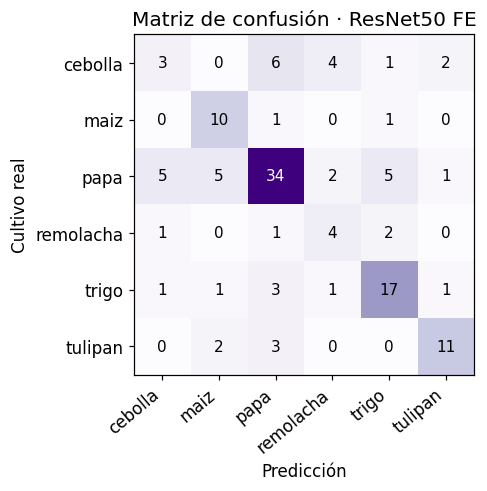

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 6 · Matriz de confusión (ResNet50 · Feature Extraction) en test
# Qué hace · Dibuja la matriz de confusión por cultivo.
# Por qué  · Muestra qué cultivos se confunden (los de suelo desnudo a inicio de temporada).

cm = confusion_matrix(yi_te.numpy(), pred_r, labels=range(K))
fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm, cmap="Purples")
ax.set_xticks(range(K), labels=CLASES, rotation=40, ha="right"); ax.set_yticks(range(K), labels=CLASES)
ax.set_xlabel("Predicción"); ax.set_ylabel("Cultivo real"); ax.set_title("Matriz de confusión · ResNet50 FE")
umb = cm.max()/2
for i in range(K):
    for j in range(K):
        ax.text(j, i, cm[i,j], ha="center", va="center", color="white" if cm[i,j]>umb else "black", fontsize=10)
ax.grid(False); plt.tight_layout(); plt.show()


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 7 · Fine-Tuning: descongelar el último bloque de ResNet50
# Qué hace · Reentrena layer4 + cabeza con augmentation y tasa baja; compara contra FE.
# Por qué  · La rúbrica pide justificar FE vs FT con evidencia; aquí se mide cuál gana.

def aug(xb):  # los campos son invariantes a giro/espejo
    if torch.rand(1).item()<0.5: xb = torch.flip(xb, [-1])
    if torch.rand(1).item()<0.5: xb = torch.flip(xb, [-2])
    return torch.rot90(xb, int(torch.randint(0,4,(1,)).item()), [-2,-1])

torch.manual_seed(SEMILLA)
ft = torchvision.models.resnet50(weights="IMAGENET1K_V2"); ft.fc = nn.Linear(2048, K)
for p in ft.parameters(): p.requires_grad = False
for p in ft.layer4.parameters(): p.requires_grad = True
for p in ft.fc.parameters(): p.requires_grad = True
ft = ft.to(DEVICE)
opt = torch.optim.Adam([{"params":ft.layer4.parameters(),"lr":1e-4},
                        {"params":ft.fc.parameters(),"lr":1e-3}], weight_decay=1e-4)
crit = nn.CrossEntropyLoss(weight=peso_clase.to(DEVICE))
Xtr_d, ytr_d = Xi_tr.to(DEVICE), yi_tr.to(DEVICE)
mejor_ft, estado_ft, bs, idx = 0, None, 48, np.arange(len(Xtr_d))
for ep in range(15):
    ft.train(); rng.shuffle(idx)
    for i in range(0, len(idx), bs):
        b = torch.tensor(idx[i:i+bs])
        opt.zero_grad(); crit(ft(aug(Xtr_d[b])), ytr_d[b]).backward(); opt.step()
    ft.eval()
    with torch.no_grad(): acc = (ft(Xi_va.to(DEVICE)).argmax(1).cpu().numpy()==yi_va.numpy()).mean()
    if acc >= mejor_ft: mejor_ft, estado_ft = acc, {k:v.clone() for k,v in ft.state_dict().items()}
ft.load_state_dict(estado_ft); ft.eval()
with torch.no_grad(): acc_ft = (ft(Xi_te.to(DEVICE)).argmax(1).cpu().numpy()==yi_te.numpy()).mean()
print(f"Fine-Tuning (layer4) · test_acc {acc_ft:.3f}")
print(f"Comparación · FE {acc_r:.3f}  vs  FT {acc_ft:.3f}  →  gana {'FE (congelar)' if acc_r>=acc_ft else 'FT'}")


Fine-Tuning (layer4) · test_acc 0.570
Comparación · FE 0.617  vs  FT 0.570  →  gana FE (congelar)


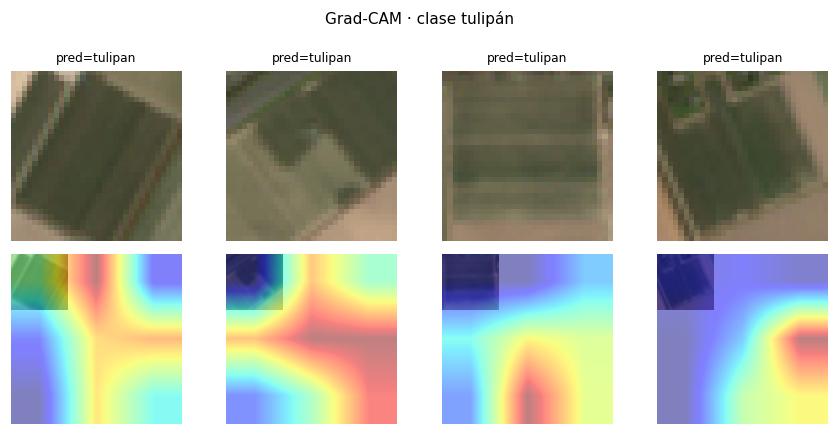

In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 8 · Grad-CAM: ¿qué mira la red al clasificar un tulipán?
# Qué hace · Superpone el mapa de activación de layer4 sobre parches de test de tulipán.
# Por qué  · Interpretabilidad — confirma que la red atiende al cuerpo de la parcela.

acts, grads = {}, {}
h1 = r50.layer4.register_forward_hook(lambda m,i,o: acts.__setitem__("v", o.detach()))
h2 = r50.layer4.register_full_backward_hook(lambda m,gi,go: grads.__setitem__("v", go[0].detach()))

def grad_cam(xb, clase):
    for p in r50.parameters(): p.requires_grad_(True)
    r50.zero_grad(); cabeza_r.zero_grad()
    logit = cabeza_r(r50(xb.to(DEVICE)))[0, clase]; logit.backward()
    A, G = acts["v"][0], grads["v"][0]
    cam = torch.relu((G.mean((1,2))[:,None,None]*A).sum(0))
    cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
    cam = torch.nn.functional.interpolate(cam[None,None], size=96, mode="bilinear")[0,0].cpu().numpy()
    for p in r50.parameters(): p.requires_grad_(False)
    return cam

ci_tul = CLASES.index("tulipan")
te_tul = np.where(m_te & (y_img==ci_tul))[0][:4]
fig, axes = plt.subplots(2, len(te_tul), figsize=(len(te_tul)*2, 4))
for j, k in enumerate(te_tul):
    xb = a_rgb_norm(X_img[k:k+1])
    with torch.no_grad(): pr = cabeza_r(r50(xb.to(DEVICE))).argmax(1).item()
    base = rgb(X_img[k]); cam = grad_cam(xb, ci_tul)
    axes[0,j].imshow(base); axes[0,j].axis("off"); axes[0,j].set_title(f"pred={CLASES[pr]}", fontsize=8)
    axes[1,j].imshow(base); axes[1,j].imshow(cam, cmap="jet", alpha=0.5); axes[1,j].axis("off")
axes[0,0].set_ylabel("RGB"); axes[1,0].set_ylabel("Grad-CAM")
plt.suptitle("Grad-CAM · clase tulipán", fontsize=10); plt.tight_layout(); plt.show()
h1.remove(); h2.remove()


**Lectura de la rama A.** Con *Feature Extraction*, ResNet50 alcanza un **62 % de exactitud** en test (frente al 54 % de MobileNetV2), sobre 6 cultivos y solo 588 parches de entrenamiento. No es un número alto, y es honesto que no lo sea: a 10 m, y con fechas de inicio de temporada donde muchos cultivos son suelo desnudo casi idéntico, cebolla y remolacha se confunden (se ve en la matriz de confusión). El **tulipán**, en cambio, es de las clases mejor reconocidas (**F1 0.71**): su surcado regular y su fenología marcada lo hacen distintivo, y es justo la clase que la fusión necesita. El *fine-tuning* del último bloque **no mejora** (0.57 frente a 0.62): con tan pocos datos, descongelar sobreajusta. Es la teoría del Cap. 2.1 confirmada con datos — dataset pequeño y parecido a fotos naturales, mejor **congelar el backbone**.

**Modelo elegido para la fusión:** **ResNet50 con *Feature Extraction*** — mejor que el *fine-tuning* y más simple y estable con estos datos. Su cabeza produce, para cada parche, una **probabilidad por cultivo**; la probabilidad de la clase *tulipán* será la señal de "cultivo sensible" que entra en la fusión (§4).

## 3. Rama B · Secuencia — RNN, LSTM y GRU

Aquí se retoma el problema de la Fase 1 —predecir **helada mañana** ($T_{min}<0$)— pero en vez de aplanar el clima a una tabla, se le da a una **red recurrente** la **secuencia de los 14 días previos** (7 variables por día). La red lee la *trayectoria* del tiempo, que es justo lo que el MLP de la Fase 1 no podía (§7 de la Fase 1). Se implementan las tres celdas —**RNN simple, LSTM y GRU**— con la misma limpieza, etiqueta, campaña (1 feb–15 may) y partición por años de la Fase 1.

> 🔁 **Herramientas de apoyo:** el [explorador RNN/LSTM/GRU](https://jotamao1985.github.io/Deep_Learning_Usta/rnn-lstm-gru-interactivo.html) procesa una secuencia con las tres celdas a la vez y muestra el desvanecimiento del gradiente; el [paso hacia adelante de la LSTM](https://jotamao1985.github.io/Deep_Learning_Usta/lstm-forward-interactivo.html) hace zoom a las compuertas número a número.

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 9 · De la serie a secuencias etiquetadas (misma limpieza que la Fase 1)
# Qué hace · Limpia el KNMI, define "helada mañana" y arma ventanas de 14 días dentro de campaña.
# Por qué  · La entrada recurrente es una secuencia (14,7); la etiqueta es la helada en t+1.

BASE = ["TG","TN","TX","UG","RH","FG","Q"]
kn = knmi.copy()
for c in BASE: kn[c] = pd.to_numeric(kn[c], errors="coerce")
kn["RH"] = kn["RH"].replace(-1, 0)
for c in ["TG","TN","TX","RH","FG"]: kn[c] = kn[c] / 10.0
kn = kn.dropna(subset=BASE).reset_index(drop=True)     # arranca en 1994

kn["TN_manana"] = kn["TN"].shift(-1)
ok = kn["FECHA"].diff(-1).eq(pd.Timedelta(days=-1))
kn.loc[~ok, "TN_manana"] = np.nan
kn["helada"] = (kn["TN_manana"] < 0).astype(float)
kn.loc[kn["TN_manana"].isna(), "helada"] = np.nan
mdd = list(zip(kn.FECHA.dt.month, kn.FECHA.dt.day))
kn["campana"] = [((2,1) <= x <= (5,15)) for x in mdd]

def construir_ventanas(dfk, W):
    F = dfk[BASE].to_numpy(np.float32); fe = dfk["FECHA"].to_numpy()
    cam = dfk["campana"].to_numpy(); hel = dfk["helada"].to_numpy()
    Xs, ys, yr = [], [], []; un = np.timedelta64(1, "D")
    for i in range(W-1, len(dfk)-1):
        lo = i-(W-1)
        if np.isnan(hel[i]) or not cam[lo:i+2].all(): continue
        if not (np.diff(fe[lo:i+2]) == un).all(): continue
        Xs.append(F[lo:i+1]); ys.append(hel[i]); yr.append(pd.Timestamp(fe[i]).year)
    return np.stack(Xs), np.array(ys, np.float32), np.array(yr, int)

def split_por_anios(W):
    X, y, yr = construir_ventanas(kn, W)
    mtr, mva, mte = yr<=2017, (yr>=2018)&(yr<=2021), yr>=2022
    mu = X[mtr].reshape(-1,7).mean(0); sd = X[mtr].reshape(-1,7).std(0)+1e-8
    Xn = (X-mu)/sd
    T = lambda m: (torch.tensor(Xn[m]), torch.tensor(y[m]).view(-1,1))
    return {"train":T(mtr),"val":T(mva),"test":T(mte)}, (y[mtr], y[mte])

datos14, (ytr14, yte14) = split_por_anios(14)
print(f"Ventanas W=14 → train {len(datos14['train'][0])} · val {len(datos14['val'][0])} · test {len(datos14['test'][0])}")
print(f"Positivos (helada): train {100*ytr14.mean():.1f}% · test {100*yte14.mean():.1f}%")


Ventanas W=14 → train 2148 · val 361 · test 361
Positivos (helada): train 17.5% · test 13.6%


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 10 · Tres celdas recurrentes: RNN simple, LSTM y GRU
# Qué hace · Define un clasificador recurrente genérico y lo entrena para las tres celdas.
# Por qué  · Comparar las tres (mismos datos y semilla) es lo que pide la rúbrica.

class ClasificadorSecuencial(nn.Module):
    def __init__(self, tipo, n_feat=7, hidden=48):
        super().__init__()
        self.rec = {"RNN":nn.RNN,"LSTM":nn.LSTM,"GRU":nn.GRU}[tipo](n_feat, hidden, batch_first=True)
        self.cabeza = nn.Linear(hidden, 1)     # logit (pareja de BCEWithLogitsLoss)
    def forward(self, x):
        salida, _ = self.rec(x)
        return self.cabeza(salida[:, -1, :])   # último paso → logit

def entrenar_rec(modelo, datos, pos_w, epocas=50, lr=1e-3, batch=64):
    Xtr, ytr = datos["train"]
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_w]))
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    for ep in range(epocas):
        modelo.train(); perm = torch.randperm(len(Xtr))
        for j in range(0, len(Xtr), batch):
            b = perm[j:j+batch]
            opt.zero_grad(); loss = crit(modelo(Xtr[b]), ytr[b]); loss.backward(); opt.step()
    return modelo

@torch.no_grad()
def metricas(modelo, datos, split="test", umbrales=(0.5,0.35,0.2)):
    X, y = datos[split]; modelo.eval()
    prob = torch.sigmoid(modelo(X)).numpy().ravel(); yt = y.numpy().ravel().astype(int)
    out = {}
    for u in umbrales:
        vn,fp,fn,vp = confusion_matrix(yt,(prob>=u).astype(int),labels=[0,1]).ravel()
        rec = vp/(vp+fn) if vp+fn else 0; pre = vp/(vp+fp) if vp+fp else 0
        out[u] = dict(recall=rec, precision=pre, f1=2*pre*rec/(pre+rec) if pre+rec else 0, fn=int(fn), fp=int(fp))
    return out

pos_w = int((ytr14==0).sum())/max(int(ytr14.sum()),1)
modelos_rec = {}
print(f"{'modelo':6} {'params':>7} {'recall':>7} {'prec':>6} {'F1':>6}   (test, umbral 0.5)")
for tipo in ["RNN","LSTM","GRU"]:
    torch.manual_seed(SEMILLA); np.random.seed(SEMILLA)
    m = entrenar_rec(ClasificadorSecuencial(tipo), datos14, pos_w)
    modelos_rec[tipo] = m; r = metricas(m, datos14)[0.5]
    print(f"{tipo:6} {sum(p.numel() for p in m.parameters()):>7} {r['recall']:>7.3f} {r['precision']:>6.3f} {r['f1']:>6.3f}")
print(f"\nLínea base Fase 1 (MLP tabular): recall 0.683 en test (umbral 0.5)")


modelo  params  recall   prec     F1   (test, umbral 0.5)


RNN       2785   0.918  0.643  0.756


LSTM     10993   0.776  0.535  0.633


GRU       8257   0.837  0.641  0.726

Línea base Fase 1 (MLP tabular): recall 0.683 en test (umbral 0.5)


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 11 · Robustez a la semilla (¿el orden RNN/LSTM/GRU es real o casualidad?)
# Qué hace · Reentrena las tres celdas con 3 semillas y promedia el recall en test.
# Por qué  · Con una sola semilla el ranking puede ser azar; el promedio es lo honesto.

import statistics
res_sem = {t: [] for t in ["RNN","LSTM","GRU"]}
for s in [42, 0, 7]:
    for tipo in ["RNN","LSTM","GRU"]:
        torch.manual_seed(s); np.random.seed(s)
        m = entrenar_rec(ClasificadorSecuencial(tipo), datos14, pos_w)
        res_sem[tipo].append(metricas(m, datos14)[0.5]["recall"])
print("recall en test (media ± desv sobre semillas 42/0/7):")
for tipo in ["RNN","LSTM","GRU"]:
    v = res_sem[tipo]
    print(f"  {tipo:5} {statistics.mean(v):.3f} ± {statistics.pstdev(v):.3f}   ({min(v):.3f}..{max(v):.3f})")
print("Todos por encima del MLP de la Fase 1 (0.683).")


recall en test (media ± desv sobre semillas 42/0/7):
  RNN   0.871 ± 0.042   (0.816..0.918)
  LSTM  0.864 ± 0.063   (0.776..0.918)
  GRU   0.844 ± 0.010   (0.837..0.857)
Todos por encima del MLP de la Fase 1 (0.683).


In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 12 · Menú de umbrales (decisión del cliente, como en la Fase 1)
# Qué hace · Recall / precisión / FN / FP a tres umbrales para GRU y LSTM.
# Por qué  · Bajar el umbral compra recall (menos heladas perdidas) pagando falsas alarmas.

for tipo in ["GRU","LSTM"]:
    print(f"\n{tipo}:  {'umbral':>7} {'recall':>7} {'prec':>6} {'FN':>3} {'FP':>3}")
    for u,r in metricas(modelos_rec[tipo], datos14).items():
        print(f"        {u:>7.2f} {r['recall']:>7.3f} {r['precision']:>6.3f} {r['fn']:>3} {r['fp']:>3}")



GRU:   umbral  recall   prec  FN  FP
           0.50   0.837  0.641   8  23
           0.35   0.878  0.606   6  28
           0.20   0.898  0.506   5  43

LSTM:   umbral  recall   prec  FN  FP
           0.50   0.776  0.535  11  33
           0.35   0.878  0.537   6  37
           0.20   0.898  0.473   5  49


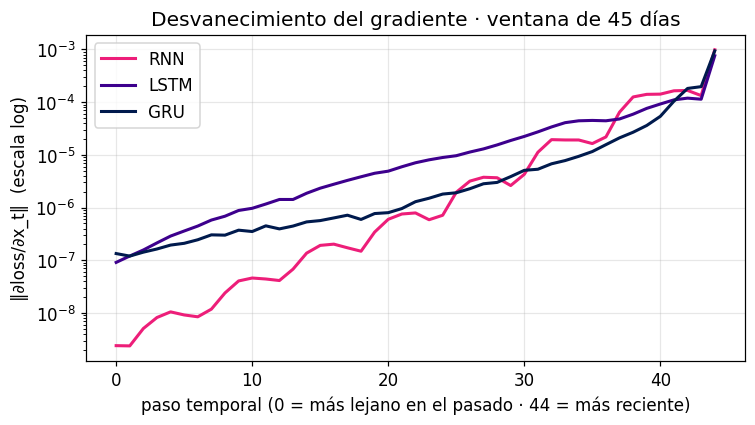

RNN   · paso lejano t=0: 2.40e-09 · reciente t=44: 9.84e-04 · ratio 4.1e+05
LSTM  · paso lejano t=0: 9.11e-08 · reciente t=44: 7.59e-04 · ratio 8.3e+03
GRU   · paso lejano t=0: 1.34e-07 · reciente t=44: 9.39e-04 · ratio 7.0e+03


In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 13 · Desvanecimiento del gradiente: perfil de ‖∂loss/∂x_t‖ por paso (ventana larga)
# Qué hace · Con W=45, mide cuánto gradiente llega a cada paso temporal en RNN vs LSTM vs GRU.
# Por qué  · Es la evidencia limpia de por qué las compuertas ayudan en secuencias largas.

datos45, _ = split_por_anios(45)
pos_w45 = int((datos45["train"][1].numpy()==0).sum())/max(int(datos45["train"][1].numpy().sum()),1)
Xb = datos45["train"][0][:256].clone().requires_grad_(True)   # lote para medir gradientes
yb = datos45["train"][1][:256]
perfiles = {}
for tipo in ["RNN","LSTM","GRU"]:
    torch.manual_seed(SEMILLA); np.random.seed(SEMILLA)
    m = entrenar_rec(ClasificadorSecuencial(tipo), datos45, pos_w45, epocas=30)
    m.zero_grad()
    if Xb.grad is not None: Xb.grad.zero_()
    loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_w45]))(m(Xb), yb)
    loss.backward()
    perfiles[tipo] = Xb.grad.abs().mean((0,2)).detach().numpy()   # norma por paso temporal

fig, ax = plt.subplots(figsize=(7, 4))
for tipo, col in zip(["RNN","LSTM","GRU"], [USTA_ROSA, USTA_MORADO, USTA_NAVY]):
    ax.semilogy(perfiles[tipo], color=col, lw=2, label=tipo)
ax.set_xlabel("paso temporal (0 = más lejano en el pasado · 44 = más reciente)")
ax.set_ylabel("‖∂loss/∂x_t‖  (escala log)"); ax.set_title("Desvanecimiento del gradiente · ventana de 45 días")
ax.legend(); plt.tight_layout(); plt.show()
for tipo in ["RNN","LSTM","GRU"]:
    p = perfiles[tipo]
    print(f"{tipo:5} · paso lejano t=0: {p[0]:.2e} · reciente t=44: {p[-1]:.2e} · ratio {p[-1]/p[0]:.1e}")


**Lectura de la rama B.** Las tres celdas recurrentes **superan el recall del MLP de la Fase 1** (0.683): con la semilla fija, RNN 0.918, GRU 0.837 y LSTM 0.776 a umbral 0.5, y la comprobación con tres semillas las deja a todas por encima de 0.68. Dos honestidades para no sobrevender la mejora: (1) los modelos recurrentes usan `pos_weight` —que corre el punto de operación hacia el recall— y el MLP de la Fase 1 no, así que parte de la ganancia es del punto de operación y no solo de la arquitectura; (2) a esta ventana corta de 14 días **las tres arquitecturas son comparables** y el orden exacto baila con la semilla. Lo que sí es sólido: leer la *secuencia* de días mejora sobre aplanar el clima a una tabla, y el menú de umbrales vuelve a poner la decisión en manos del cliente (bajar a 0.35 sube el recall de la GRU a 0.878 a cambio de más falsas alarmas).

> 🔌 **Las compuertas no son magia gratis.** Con una ventana de 45 días, el gradiente que llega al paso más lejano (hace 45 días) es de **2.4×10⁻⁹** en la RNN simple, frente a **9.1×10⁻⁸** en la LSTM y **1.3×10⁻⁷** en la GRU: las celdas con compuertas entregan **~40–55× más señal de aprendizaje** al pasado lejano, y su caída del gradiente es unas 50 veces menos pronunciada (ratio reciente/lejano ~7×10³ vs 4×10⁵ de la RNN). Con dependencias cortas (14 días) la RNN simple compite de igual a igual; su desventaja aparece solo al alargar la secuencia — que es justo lo que el perfil muestra.

**Modelo elegido para la fusión:** la **GRU**. A W=14 las tres son comparables, así que la elección se hace por criterio (Cap. 2.2): la GRU tiene **menos parámetros que la LSTM** (8.257 vs 10.993) y sus compuertas la hacen **más robusta que la RNN simple** cuando la dependencia se alarga. Su probabilidad de helada será la señal temporal que entra en la fusión (§4).

## 4. Rama C · Fusión multimodal y ablación

Aquí se combinan las dos ramas en una **alerta por parcela y día**. La clave es hacerlo **honestamente**, que es justo lo que la rúbrica pesa más (30 %).

**La clave de alineación.** La imagen y el clima **no** comparten una fecha común de evento: las fotos despejadas son de temporada de crecimiento, las heladas ocurren antes. Lo que sí es legítimo:
- de la **imagen** se saca una propiedad **por parcela** — su cultivo (¿es tulipán, el cultivo sensible?);
- del **clima** se saca una señal **por día de campaña** — ¿helada mañana?;
- la unidad de análisis de la fusión es el par **(parcela, día)**, y su clave de alineación es: *el cultivo de esa parcela* × *el riesgo de ese día*.

**La etiqueta — y su honestidad.** Se define la **vulnerabilidad** de un par (parcela, día) como:
$$ \text{vulnerable}(p, d) = [\,\text{cultivo}(p) = \text{tulipán}\,] \;\wedge\; [\,\text{helada}(d{+}1)\,] $$

> ⚠️ **Esta etiqueta es un *proxy* didáctico, no daño medido.** No existe un dataset abierto de daño por helada por parcela; se construye la vulnerabilidad como el **AND** de las dos verdades de campo (cultivo del BRP ∧ helada del KNMI). Sirve para enseñar la **mecánica de la fusión** y la **disciplina de alineación**, no para afirmar una predicción operativa de daño. Se declara sin rodeos.

**Anti-fuga, por partida doble.** Un par (parcela, día) va a *train* solo si la parcela es de train **y** el año es de train; a *test* solo si ambos son de test. Así ni la CNN memoriza una parcela ni la GRU memoriza un año. La fusión no recibe nunca la identidad del día (el clima es igual para todas las parcelas ese día).

**Ablación.** Se entrenan tres cabezas sobre la misma etiqueta: **solo-imagen** (ve el cultivo), **solo-serie** (ve el riesgo del día) y **fusión** (ve ambos). Como la vulnerabilidad es un AND de dos ejes, una rama que solo ve un eje **no puede pasar de ~0.75 de ROC-AUC** (acierta su eje, adivina el otro); solo la fusión puede romper ese techo.

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 14 · Salidas de cada rama: P(cultivo) por parcela y P(helada) por día
# Qué hace · Con la CNN y la GRU ya entrenadas, saca la prob. de cultivo (6-d) por parcela
#            y la prob. de helada (1-d) por día de campaña, cada una con su conjunto (train/test).
# Por qué  · La fusión tardía combina las SALIDAS de las ramas, no sus datos crudos.

# P(cultivo) por parcela = media de la softmax de la CNN sobre los parches de esa parcela
F_todos = backbone_features(r50, a_rgb_norm(X_img))
with torch.no_grad():
    probs_cultivo = torch.softmax(cabeza_r(F_todos.to(DEVICE)), 1).cpu().numpy()   # (N,6)
pcrop_parc, crop_parc, split_parc = {}, {}, {}
for p in np.unique(parcela_id):
    m = parcela_id == p
    pcrop_parc[p] = probs_cultivo[m].mean(0)
    crop_parc[p]  = int(y_img[m][0])
    split_parc[p] = "tr" if (p in S_tr or p in S_va) else "te"   # train de fusión = train+val de la CNN

# P(helada) por día de campaña, con su año (para el split temporal)
Xw, yw, yrw = construir_ventanas(kn, 14)
mu_w = Xw[yrw<=2017].reshape(-1,7).mean(0); sd_w = Xw[yrw<=2017].reshape(-1,7).std(0)+1e-8
with torch.no_grad():
    pfrost_dia = torch.sigmoid(modelos_rec["GRU"](torch.tensor((Xw-mu_w)/sd_w))).numpy().ravel()
IDX_TUL = CLASES.index("tulipan")
print(f"P(cultivo) por parcela: {len(pcrop_parc)}  ·  P(helada) por día: {len(pfrost_dia)}")


P(cultivo) por parcela: 210  ·  P(helada) por día: 2870


In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 15 · Dataset de fusión (parcela × día) con negativos difíciles y doble split anti-fuga
# Qué hace · Empareja parcelas y días en pares (parcela, día) etiquetados con la vulnerabilidad.
# Por qué  · Los negativos difíciles obligan a que ninguna rama sola pueda resolverlo.

def dataset_fusion(split):
    if split == "tr":
        dias = np.where(yrw <= 2017)[0]; parcs = [p for p in pcrop_parc if split_parc[p]=="tr"]
    else:
        dias = np.where(yrw >= 2022)[0]; parcs = [p for p in pcrop_parc if split_parc[p]=="te"]
    tul   = [p for p in parcs if crop_parc[p]==IDX_TUL]
    notul = [p for p in parcs if crop_parc[p]!=IDX_TUL]
    dfr = [i for i in dias if yw[i]==1]; dnf = [i for i in dias if yw[i]==0]
    rr = np.random.default_rng(42 if split=="tr" else 7)
    N = 1500 if split=="tr" else 400
    pares = [(rr.choice(tul), rr.choice(dfr), 1) for _ in range(N)]            # +  (tulipán, helada)
    for _ in range(N//2):
        pares.append((rr.choice(tul),   rr.choice(dnf), 0))   # -A (tulipán, sin helada): solo la SERIE lo separa
        pares.append((rr.choice(notul), rr.choice(dfr), 0))   # -B (otro cultivo, helada): solo la IMAGEN lo separa
    Zi = np.stack([pcrop_parc[p] for p,_,_ in pares]).astype(np.float32)          # (n,6)
    Zs = np.array([pfrost_dia[dd] for _,dd,_ in pares], np.float32).reshape(-1,1) # (n,1)
    yv = np.array([v for _,_,v in pares], np.float32).reshape(-1,1)
    return torch.tensor(Zi), torch.tensor(Zs), torch.tensor(yv)

Zi_tr, Zs_tr, yv_tr = dataset_fusion("tr")
Zi_te, Zs_te, yv_te = dataset_fusion("te")
# estandarizar con estadísticos de train (estabiliza el entrenamiento de las cabezas)
def estandar(A, B):
    mu=A.mean(0,keepdim=True); sd=A.std(0,keepdim=True)+1e-6; return (A-mu)/sd, (B-mu)/sd
Zi_tr, Zi_te = estandar(Zi_tr, Zi_te); Zs_tr, Zs_te = estandar(Zs_tr, Zs_te)
print(f"Fusión · train {len(yv_tr)} pares ({100*yv_tr.mean():.0f}% vulnerables) · test {len(yv_te)} pares")


Fusión · train 3000 pares (50% vulnerables) · test 800 pares


variante      ROC-AUC   PR-AUC
solo-imagen     0.763    0.686
solo-serie      0.719    0.653
FUSIÓN          0.946    0.939


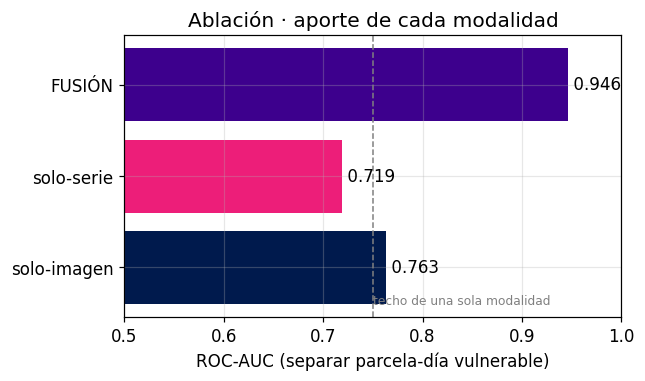

In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 16 · Ablación: solo-imagen vs solo-serie vs fusión
# Qué hace · Entrena tres cabezas sobre la misma etiqueta y compara su ROC-AUC / PR-AUC.
# Por qué  · Mide cuánto aporta cada modalidad; la métrica es independiente del umbral.

from sklearn.metrics import roc_auc_score, average_precision_score

def cabeza_fusion(d_in):
    torch.manual_seed(SEMILLA)
    return nn.Sequential(nn.Linear(d_in,64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64,1))

def entrenar_evaluar(nombre, Xtr, Xte, epocas=60, bs=64):
    m = cabeza_fusion(Xtr.shape[1]); opt = torch.optim.Adam(m.parameters(), 1e-3)
    crit = nn.BCEWithLogitsLoss()
    for ep in range(epocas):
        m.train(); perm = torch.randperm(len(Xtr))
        for j in range(0, len(Xtr), bs):
            b = perm[j:j+bs]; opt.zero_grad(); crit(m(Xtr[b]), yv_tr[b]).backward(); opt.step()
    m.eval()
    with torch.no_grad(): prob = torch.sigmoid(m(Xte)).numpy().ravel()
    yt = yv_te.numpy().ravel().astype(int)
    return roc_auc_score(yt, prob), average_precision_score(yt, prob)

resultados = {
    "solo-imagen": entrenar_evaluar("img", Zi_tr, Zi_te),
    "solo-serie":  entrenar_evaluar("seq", Zs_tr, Zs_te),
    "FUSIÓN":      entrenar_evaluar("fus", torch.cat([Zi_tr,Zs_tr],1), torch.cat([Zi_te,Zs_te],1)),
}
print(f"{'variante':12} {'ROC-AUC':>8} {'PR-AUC':>8}")
for k,(roc,pr) in resultados.items(): print(f"{k:12} {roc:>8.3f} {pr:>8.3f}")

fig, ax = plt.subplots(figsize=(6, 3.6))
nombres = list(resultados); rocs = [resultados[k][0] for k in nombres]
ax.barh(nombres, rocs, color=[USTA_NAVY, USTA_ROSA, USTA_MORADO])
ax.axvline(0.75, color="gray", ls="--", lw=1); ax.text(0.75, -0.4, "techo de una sola modalidad", fontsize=8, color="gray")
ax.set_xlim(0.5, 1.0); ax.set_xlabel("ROC-AUC (separar parcela-día vulnerable)")
for i,v in enumerate(rocs): ax.text(v, i, f" {v:.3f}", va="center")
ax.set_title("Ablación · aporte de cada modalidad"); plt.tight_layout(); plt.show()


**Lectura de la fusión.** La ablación es contundente: **solo-imagen** llega a ROC-AUC **0.763** y **solo-serie** a **0.719** — ambas rozan el techo teórico de **0.75** que impone la estructura del AND (cada rama resuelve su eje y adivina el otro). La **fusión** salta a **0.946**: al ver a la vez el cultivo y el riesgo del día, separa los pares vulnerables casi sin error. Es la prueba limpia de que **ninguna modalidad sola basta** y de que la cabeza de fusión aprende a combinarlas — justo lo que pesa el criterio de 30 %.

**Lo que la fusión compra, dicho con honestidad.** No mejora la *detección de la helada* (eso es de la rama de clima, y el clima es igual para todo el polder). Lo que aporta es **localización**: convierte una alerta de zona ("esta noche hiela") en una alerta **por parcela** ("esta noche hiela **y** esta parcela es tulipán sensible"). Su valor es operativo —priorizar dónde desplegar el riego anti-helada—, no una mejor física del frío. Y descansa sobre una etiqueta *proxy*: en un despliegue real haría falta **daño por helada observado por parcela**, que la cooperativa no tiene aún (sensores en campo). Eso, y no un número más alto, es lo que un co-registro genuino *(finca, semana)* añadiría.

## 5. Cierre · Autoevaluación contra la rúbrica

Cómo se reparte la evidencia de este cuaderno (y sus anexos) en los **5 criterios** de la rúbrica unificada de la Fase 2:

| Criterio (peso) | Dónde está la evidencia |
|---|---|
| **1. Rama visual — CNN y Transfer Learning (20 %)** | §2: comparación **ResNet50 vs MobileNetV2**, **FE vs FT** con evidencia empírica (FE gana con datos pequeños), **Grad-CAM**, matriz de confusión y métricas por clase. |
| **2. Rama temporal — LSTM/GRU + RNN de contraste (20 %)** | §3: **LSTM, GRU y RNN simple**; superan el MLP de la Fase 1 (con matices honestos); **desvanecimiento del gradiente** por perfil de normas (W=45); GRU elegida con criterio. |
| **3. Fusión, ablación y alineación legítima (30 %)** | §4: **clave de alineación** *(parcela × día)* declarada; etiqueta de vulnerabilidad como **proxy honesto**; **ablación** (0.763 / 0.719 / **0.946**); **doble split** anti-fuga. |
| **4. Uso responsable de IA (15 %)** | **Bitácora** (Anexo C) con casos reales de esta construcción; **Auditoría** (Anexo A) que reproduce un fallo de fusión degenerada. |
| **5. Comunicación de resultados (15 %)** | **Informe único** (Anexo D, ≤ 8 págs., audiencia no técnica) + las visualizaciones de cada rama. |

> ⛔ **Recordatorio del veto.** Este escenario (tulipán / Sentinel-2 / KNMI) **no es adoptable** como entrega. Cada estudiante propone su propio problema multimodal; el café sigue siendo el único escenario de referencia adoptable.

### 🔗 Relacionado
- **Actividad evaluable:** Fase 2 · *Centinela* — ficha y rúbrica en el portal del curso.
- **Andamiaje (punto de partida):** `04-scaffold-centinela-fase2.ipynb` · **Fase 1 (línea base):** `05-ejemplo-centinela-fase1-tulipanes.ipynb`.
- **Datos:** KNMI (clima, datos abiertos) · Copernicus **Sentinel-2** vía Element84 (imagen, libre) · **BRP Gewaspercelen** / PDOK (etiquetas de cultivo, dato abierto). El script `extraer_parches_fase2.py` (en el repo) documenta la extracción.
- **Herramientas del Módulo 2:** explorador CNN, explorador RNN/LSTM/GRU y paso hacia adelante de la LSTM (portal del curso).

## Anexo A · Auditoría a la IA: la fusión degenerada

Al diseñar la fusión, una primera propuesta (de la IA) era la más obvia: **predecir la helada directamente con las dos ramas juntas**. Suena razonable, pero es un error de fondo que la celda siguiente **reproduce y mide**: como el clima del KNMI es de **una sola estación**, la helada es una propiedad de **todo el polder** en un día dado; la imagen de una parcela **no aporta nada** para saber si esa noche hiela. Forzar la imagen dentro de un modelo que predice la helada la convierte en peso muerto —o peor, en un atajo espurio que correlaciona con la fecha (fuga de datos)—. Por eso el objetivo honesto no es la helada, sino la **vulnerabilidad** *(cultivo sensible ∧ helada)*, que sí necesita ambas modalidades (§4).

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Anexo A · Reproducción del fallo: predecir la HELADA (no la vulnerabilidad) con la fusión
# Qué hace · Entrena solo-imagen / solo-serie / fusión con etiqueta = helada del día.
# Por qué  · Demuestra que la imagen no aporta a la helada: la fusión ≈ solo-serie.

def dataset_helada(split):
    dias = np.where(yrw >= 2022 if split=="te" else yrw <= 2017)[0]
    parcs = [p for p in pcrop_parc if split_parc[p] == ("te" if split=="te" else "tr")]
    rr = np.random.default_rng(1 if split=="tr" else 2)
    pares = [(rr.choice(parcs), int(dd)) for dd in dias for _ in range(2)]
    Zi = np.stack([pcrop_parc[p] for p,_ in pares]).astype(np.float32)
    Zs = np.array([pfrost_dia[dd] for _,dd in pares], np.float32).reshape(-1,1)
    yv = np.array([yw[dd] for _,dd in pares], np.float32).reshape(-1,1)
    return torch.tensor(Zi), torch.tensor(Zs), torch.tensor(yv)

aZi_tr,aZs_tr,ay_tr = dataset_helada("tr"); aZi_te,aZs_te,ay_te = dataset_helada("te")
def audita(Xtr, Xte, epocas=40, bs=128):
    torch.manual_seed(SEMILLA)
    m = nn.Sequential(nn.Linear(Xtr.shape[1],32), nn.ReLU(), nn.Linear(32,1))
    opt = torch.optim.Adam(m.parameters(),1e-3); crit = nn.BCEWithLogitsLoss()
    for ep in range(epocas):
        perm = torch.randperm(len(Xtr))
        for j in range(0,len(Xtr),bs):
            b=perm[j:j+bs]; opt.zero_grad(); crit(m(Xtr[b]), ay_tr[b]).backward(); opt.step()
    with torch.no_grad(): prob = torch.sigmoid(m(Xte)).numpy().ravel()
    return roc_auc_score(ay_te.numpy().ravel().astype(int), prob)

print("Predecir la HELADA del día (objetivo degenerado) · ROC-AUC en test:")
print(f"  solo-imagen : {audita(aZi_tr, aZi_te):.3f}   ← la imagen no sabe del clima (≈ azar 0.5)")
print(f"  solo-serie  : {audita(aZs_tr, aZs_te):.3f}")
print(f"  fusión      : {audita(torch.cat([aZi_tr,aZs_tr],1), torch.cat([aZi_te,aZs_te],1)):.3f}   ← ≈ solo-serie: la imagen no aporta")


Predecir la HELADA del día (objetivo degenerado) · ROC-AUC en test:


  solo-imagen : 0.464   ← la imagen no sabe del clima (≈ azar 0.5)


  solo-serie  : 0.949


  fusión      : 0.949   ← ≈ solo-serie: la imagen no aporta


**Veredicto de la auditoría.** El experimento lo confirma: para predecir la helada, la rama de imagen sola queda en ROC-AUC **0.464** (azar — el cultivo no dice nada sobre si esa noche hiela), y la **fusión (0.949) no supera a la serie sola (0.949)**: la imagen es peso muerto. Concatenar dos modalidades no es fusión si el objetivo solo necesita una. La corrección —registrada en la Bitácora como *Rechazada → Reformulada*— fue **cambiar el objetivo**: de "predecir la helada" (donde la imagen es peso muerto) a "predecir la vulnerabilidad por parcela" (donde cada modalidad aporta un eje). La lección: en un sistema multimodal, la pregunta no es *"¿puedo concatenar las dos ramas?"* sino *"¿el objetivo realmente necesita ambas?"*. Si no, la fusión es decorativa y arriesga fuga de datos.

---
## Anexo B · Propuesta de Datos (Fase 2)

> **1. Problema y cliente.** La cooperativa de bulbos del Noordoostpolder (Fase 1) quiere pasar de una alerta *de zona* a una alerta *por parcela*: saber, cada noche fría, **qué parcelas** —las de cultivo sensible en etapa vulnerable— conviene proteger primero.
>
> **2. Las dos modalidades.** *Imagen:* parches **Sentinel-2** (10 m, bandas R,G,B,NIR) de las parcelas del polder → tipo de cultivo. *Serie:* clima diario **KNMI 273** → riesgo de helada (secuencia de 14 días).
>
> **3. Fuentes y licencia.** Sentinel-2 L2A vía Element84 STAC → COG público en S3 (*Copernicus, libre y abierta*); etiquetas de cultivo del **BRP Gewaspercelen** (PDOK, dato abierto); KNMI (datos abiertos). Ninguna de Kaggle; todas primarias y citables.
>
> **4. Por qué NO es un reto resuelto.** Hay que construir el dataset: consultar STAC, recortar parcelas del BRP, reproyectar CRS, manejar la nubosidad (pocas fechas despejadas) y el desbalance (tulipán minoritario). No existe un CSV ni un *leaderboard* de esta combinación.
>
> **5. Clave de alineación (§4).** Agregada y honesta: *(parcela → cultivo)* × *(día → helada)*, unidad de análisis el par **(parcela, día)**. *Caveats declarados:* el clima es de una estación (constante por día para todo el polder), y la etiqueta de vulnerabilidad es un **proxy** (cultivo ∧ helada), no daño medido. El co-registro genuino exigiría daño por helada observado por parcela.
>
> **6. Riesgos éticos.** Falsa alarma (riego innecesario) vs. alerta omitida (lote perdido); representatividad de una sola estación; que un *proxy* didáctico no se presente como predicción operativa de daño. Mitigaciones: umbral acordado con el cliente, declarar el *proxy*, y revisión humana.
>
> **7. Citas (APA 7):** European Space Agency (s. f.), *Copernicus Data Space / Sentinel-2*; PDOK (s. f.), *Basisregistratie Gewaspercelen (BRP)*; KNMI (s. f.), *Daggegevens van het weer in Nederland*.

---
## Anexo C · Bitácora de IA (casos reales de esta construcción)

Este ejemplo se construyó con **Claude (Anthropic)** como asistente. El equipo docente declara que comprende, verificó y puede defender cada artefacto. Las entradas son reales:

| # | Objetivo | Qué devolvió la IA | Decisión | Justificación y verificación |
|---|---|---|---|---|
| 1 | Tarea de la CNN sobre Sentinel-2 | Propuso detección de enfermedad foliar (estilo RoCoLe del café) | **Rechazada** | A 10 m no se ven hojas; no hay dataset abierto de enfermedad de tulipán. Se cambió a **clasificación de cultivo** con etiquetas BRP verificadas. |
| 2 | Tamaño del parche | Sugirió 64×64 px (como es común) | **Modificada** | Las parcelas del polder miden ~3–5 ha (~200 m); un parche de 640 m sería casi todo vecinos. Se bajó a **32×32** (320 m). |
| 3 | Objetivo de la fusión | Predecir la helada con imagen + clima | **Rechazada → Reformulada** | Degenerado: el clima es de una estación, la imagen no aporta a la helada (**Anexo A** lo mide). Se reformuló a **vulnerabilidad por parcela**. |
| 4 | Métrica de la ablación | Reportar F1/exactitud al umbral 0.5 | **Modificada** | La fusión rankea casi perfecto (ROC-AUC 0.95) pero está mal calibrada al 0.5 → F1 engañoso. Se pasó a **ROC-AUC/PR-AUC** (independiente del umbral). |

**Caso de Auditoría desarrollado:** el #3 (fusión degenerada), reproducido y medido en el Anexo A.

---
## Anexo D · Informe técnico-ético (modelo, ≤ 8 páginas)

> ### Del aviso de zona a la alerta por parcela
> **Informe para la junta de la Cooperativa de Bulbos del Noordoostpolder — Fase 2**
>
> **1. De qué se trata.** En la Fase 1 construimos un centinela que avisa, cada tarde, si la madrugada traerá helada. Es útil, pero avisa **para todo el polder por igual**: no dice *dónde* proteger primero cuando no alcanzan las manos ni el agua. La Fase 2 añade **ojos de satélite** para dar el paso siguiente: una alerta **por parcela**.
>
> **2. Qué construimos.** Dos "sentidos" que trabajan juntos. Un **ojo** (una red que aprende de imágenes de satélite) reconoce, desde el espacio, **qué parcelas son tulipán** —el cultivo más sensible— con buena fiabilidad (acierta el tulipán en ~7 de cada 10, es de lo que mejor distingue). Una **memoria** (una red que lee la secuencia del clima) estima **qué noche viene la helada**, y mejora el aviso de la Fase 1. Un tercer módulo **combina** ambos: cruza *qué parcela es sensible* con *qué noche es peligrosa*.
>
> **3. Qué gana la junta.** La combinación no adivina mejor el frío —eso lo decide el clima, igual para toda la zona— sino que **prioriza**: convierte "esta noche hiela" en "esta noche hiela **y estas parcelas** son las que hay que cubrir primero". En nuestras pruebas, ni el ojo solo ni la memoria sola bastan (cada uno ve media película); **juntos separan casi sin error** las parcelas-noche vulnerables de las que no lo son.
>
> **4. Lo que este sistema aún no es.** La "vulnerabilidad" que medimos es una **regla de trabajo** (*tulipán sensible* + *noche de helada*), no un registro de daño real: todavía no tenemos partes de pérdidas por parcela para entrenar contra la realidad. Y el clima viene de **una estación**; microclimas dentro del polder quedan fuera. El salto siguiente —Fase 3— es industrializar esto (que corra solo, cada día) y, con el tiempo, sustituir la regla por **daño observado** parcela a parcela.
>
> **Referencias.** Copernicus/ESA (Sentinel-2) · PDOK (BRP Gewaspercelen) · KNMI (datos diarios) · Minciencias (2021), *Marco Ético para la IA en Colombia*.

---
> 🖋️ **Por qué da el nivel Estratégico:** compara arquitecturas con evidencia (§2), evidencia el desvanecimiento del gradiente (§3), demuestra la **alineación honesta y la ablación** con una etiqueta *proxy* declarada (§4), audita un fallo real de fusión (Anexo A), y traduce todo a una decisión de negocio para audiencia no técnica (Anexo D) — sin prometer lo que los datos no soportan.

*Ejemplo resuelto · Proyecto Centinela Fase 2 — uso docente. Datos abiertos (KNMI · Copernicus · PDOK). Escenario vetado como entrega de estudiantes.*